# Deep Learning Assignment 2026 — Starting Code

## Loading Dataset

You can download the dataset from
https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images

The Lung and Colon Cancer Histopathological Image Dataset (LC25000) consists of 25,000
histopathological images from 5 classes, with 5,000 images per class:

| Folder | Class |
| --- | --- |
| `colon_aca` | Colon adenocarcinoma |
| `colon_n` | Benign colonic tissue |
| `lung_aca` | Lung adenocarcinoma |
| `lung_n` | Benign lung tissue |
| `lung_scc` | Lung squamous cell carcinoma |

The cells below download the dataset, read all 25,000 images and resize them from
768 x 768 to **120 x 120**.

**Before you start:** Runtime -> Change runtime type -> **T4 GPU**. On a CPU runtime the
models in this assignment take many times longer to train.

### Step 1 — Download the dataset

`kagglehub` downloads the dataset and returns the path to it. You need a free Kaggle
account. If you are asked to authenticate, go to your Kaggle account page
(**Settings -> API -> Create New Token**), which downloads a `kaggle.json` file containing
your username and key, and enter those when prompted.

The first run downloads about 1.9 GB. Later runs reuse the cached copy.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")

print("Path to dataset files:", path)

### Step 2 — Check the folder structure

Run this before the loading step. If the paths are wrong you will see it here immediately,
rather than after 25,000 error messages.

In [5]:
import os

# Use the active notebook/runtime folder as the base root
# cwd = os.getcwd()
# print("Current working directory:", cwd)
# path = os.path.abspath(os.path.join(path, os.pardir, os.pardir))
# root = os.path.join(path, "lung_colon_image_set")
# root = os.path.join(path, "lung_colon_image_set")

root = "../data/lung_colon_image_set"

for r, dirs, fnames in os.walk(root):
    depth = r.replace(root, "").count(os.sep)
    print("  " * depth + os.path.basename(r) + f"  ({len(fnames)} files)")

lung_colon_image_set  (1 files)
  lung_image_sets  (1 files)
    lung_aca  (5000 files)
    lung_n  (5000 files)
    lung_scc  (5000 files)
  colon_image_sets  (1 files)
    colon_n  (5000 files)
    colon_aca  (5000 files)


### Step 3 — Load and resize the images

This takes a few minutes. Three things keep it as fast as possible:

* `Image.draft()` makes the JPEG decoder work at 192 x 192 instead of 768 x 768, skipping
  most of the decode cost before any resizing happens.
* A thread pool — PIL releases the GIL while decoding, so this actually parallelises.
* The output array is preallocated, so there is no build-a-list-then-copy step.

The result is cached to `/content`, so restarting the kernel does not cost you the whole
loop again.

The images are kept as `uint8` (values 0-255) on purpose: the full array is about 1.1 GB in
`uint8` but would be 4.3 GB as `float32`. Keras casts each batch to float automatically
during training, so you do not need to convert the whole array yourself.

In [6]:
from pathlib import Path

cwd = os.getcwd()
data_dir = os.path.abspath(os.path.join(cwd, os.pardir))
content_dir = Path(data_dir) / "data/content"

print(content_dir)

/Users/lordmana/projects/Lung-and-Colon-Cancer-Classification/data/content


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

# CACHE = "/content/lc25000_120.npz"
CACHE = Path(content_dir) / "lc25000_120.npz"
IMG_SIZE = (120, 120)

# Relative path of each class directory inside the dataset
class_dirs = {
    "colon_aca": "colon_image_sets/colon_aca",
    "colon_n":   "colon_image_sets/colon_n",
    "lung_aca":  "lung_image_sets/lung_aca",
    "lung_n":    "lung_image_sets/lung_n",
    "lung_scc":  "lung_image_sets/lung_scc",
}

if os.path.exists(CACHE):
    z = np.load(CACHE, allow_pickle=True)
    data, class_labels = z["data"], z["labels"]
    print("loaded from cache")
else:
    # Collect the file list first, so we can preallocate and parallelise
    files, labels = [], []
    for class_name, rel_path in class_dirs.items():
        class_path = os.path.join(root, rel_path)
        names = sorted(f for f in os.listdir(class_path)
                       if f.lower().endswith((".jpeg", ".jpg")))
        print(f"{class_name}: {len(names)} files")
        files += [os.path.join(class_path, n) for n in names]
        labels += [class_name] * len(names)

    data = np.zeros((len(files), *IMG_SIZE, 3), dtype=np.uint8)

    def load(i):
        with Image.open(files[i]) as image:
            image.draft("RGB", IMG_SIZE)     # decode at 192x192 instead of 768x768
            data[i] = np.asarray(image.convert("RGB").resize(IMG_SIZE, Image.LANCZOS))

    with ThreadPoolExecutor(max_workers=8) as ex:
        list(tqdm(ex.map(load, range(len(files))), total=len(files), desc="loading"))

    class_labels = np.array(labels)
    np.savez(CACHE, data=data, labels=class_labels)
    print("cached to", CACHE)

print(data.shape, data.dtype)
print(np.unique(class_labels, return_counts=True))

loaded from cache
(25000, 120, 120, 3) uint8
(array(['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc'],
      dtype='<U9'), array([5000, 5000, 5000, 5000, 5000]))


### Optional — keep a copy on your Google Drive

The Colab disk is wiped when your runtime is deleted. Running this cell saves the arrays to
your Drive so you can reload them in a later session without repeating Steps 1-3.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
#
# save_folder = "/content/drive/MyDrive/Deep_Learning_2026/Assignment/"
# os.makedirs(save_folder, exist_ok=True)
# np.save(save_folder + "data.npy", data)
# np.save(save_folder + "labels_name.npy", class_labels)
#
# # ...and to load them again in a later session:
# # data = np.load(save_folder + "data.npy")
# # class_labels = np.load(save_folder + "labels_name.npy")

---
## Preprocessing

Convert the target values using the proper function for one-hot encoding, and create
train, validation and test sets using stratified train-test splits with proportions of
60% / 20% / 20% and a random seed of 42.

In [19]:
RANDOM_SEED = 42

In [1]:
import tensorflow as tf

2026-09-17 15:03:14.532889: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [22]:
# Convert class names to the integer indices expected by one-hot.
class_index = {class_name: index for index, class_name in enumerate(class_dirs)}
class_indices = np.array([class_index[class_name] for class_name in class_labels])
labels = np.array(tf.one_hot(class_indices, depth=len(class_index)))

In [23]:
print(labels)

[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    data, 
    labels, 
    test_size=0.4, 
    random_state=RANDOM_SEED, 
    stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.5, 
    random_state=RANDOM_SEED, 
    stratify=y_temp
)

## Visualizing Sample Images

Randomly select 15 samples and display each image with its label as text on top of the
image, arranged in a single figure.

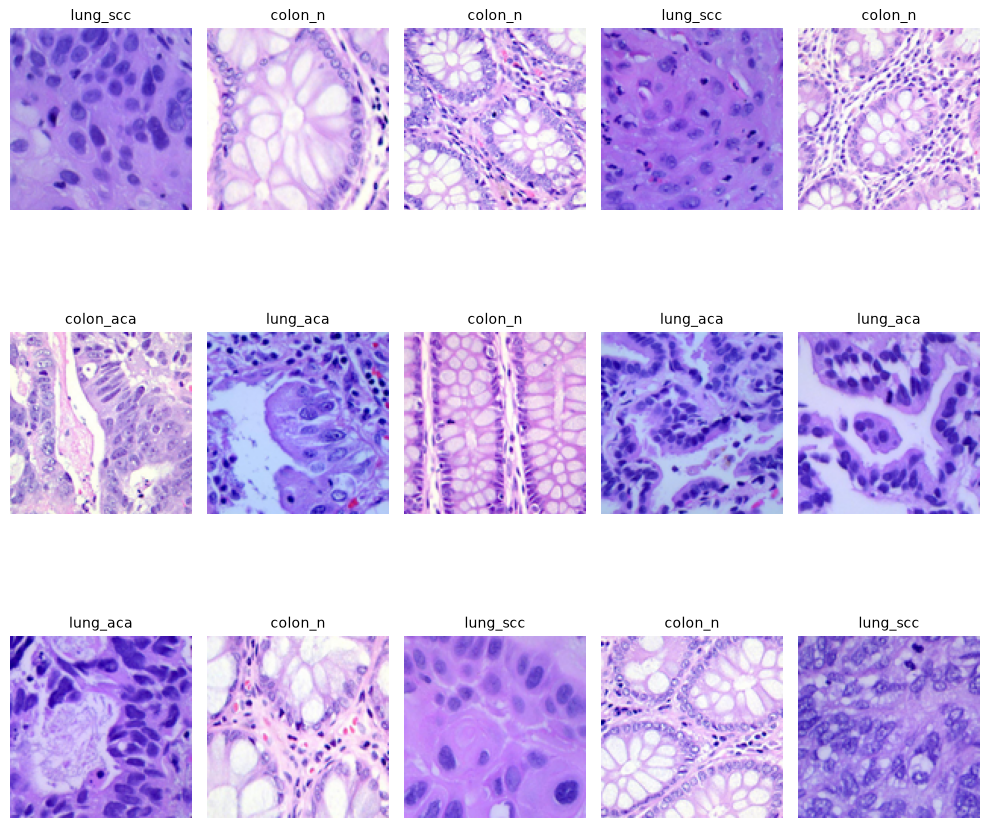

In [30]:
images_random = np.random.choice(len(data), size=15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(10, 10))
axes = axes.flatten()

for i, j in enumerate(images_random):
    img = data[j]
    label = class_labels[j]
    
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=10)
    
    axes[i].axis("off")
    
plt.tight_layout()
plt.show()

## Visualize Class Label Distribution

Create a bar plot showing how many samples the dataset has for each class.

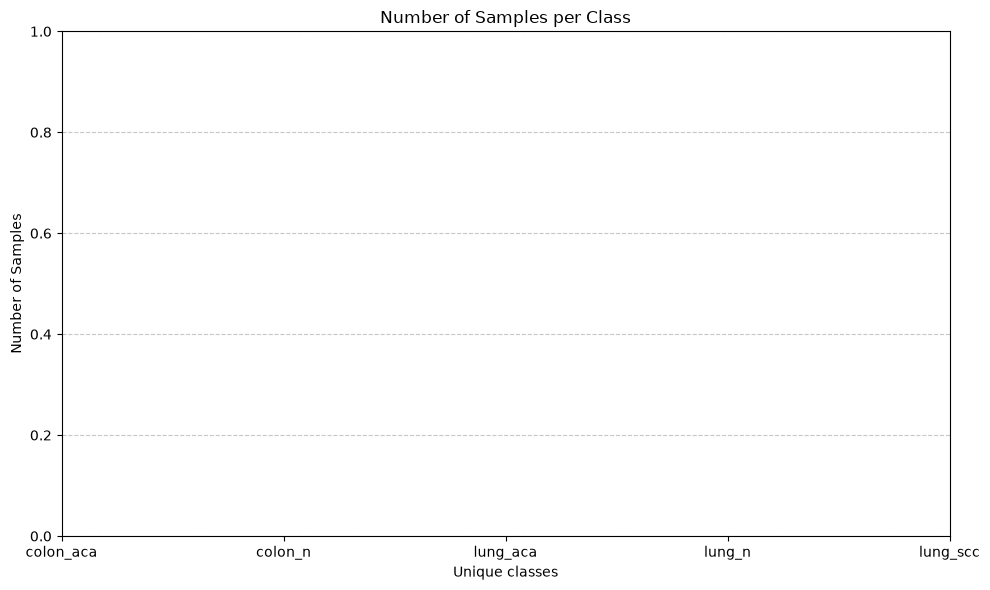

In [ ]:
unique_classes, class_counts = np.unique(class_labels, return_counts=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(unique_classes, class_counts)

ax.set_title('Number of Samples per Class')
ax.set_xlabel('Unique classes')
ax.set_ylabel('Number of Samples')

ax.set_xticks(range(len(unique_classes)))
ax.set_xticklabels(unique_classes)

ax.grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout()
plt.show()

## Baseline Model

Implement the baseline CNN exactly as described in the assignment, train it for 15 epochs
with a batch size of 32, and analyse its performance (accuracy/loss curves, ROC curve with
AUC, confusion matrix, and performance measures for the validation and test sets).

## Enhanced Model

Adapt the baseline by intentionally tweaking at least six different hyperparameters, and
compare the results against the baseline.